# 대청댐 유해남조류 발생 예측 AI 모델

## 프로젝트 개요

대청댐에서 주기적으로 수집·측정한 **수질정보, 댐 운영정보, 기상정보**를 바탕으로:

1. **유해남조류 발생 및 조류경보 발령 시점 예측 AI 모델 개발**
2. **녹조 발생 주요 영향 인자 도출**

을 통해 **사전 시나리오 기반 의사결정 지원체계**를 구축하고, 선제적 수질관리 및 비용·리스크 감소를 목표로 한다.

---

### 유해남조류 4종
| 종 | 설명 |
|---|---|
| *Microcystis* | 독소(마이크로시스틴) 생성, 가장 흔한 유해남조류 |
| *Anabaena* | 아나톡신·마이크로시스틴 생성 가능 |
| *Oscillatoria* | 수온 변화에 강인, 심층까지 분포 |
| *Aphanizomenon* | 삭시톡신 생성 가능 |

### 조류경보제 발령 기준 (유해남조류 cells/mL)
| 단계 | 기준 |
|---|---|
| 미발령 | 1,000 미만 |
| 관심 | 1,000 이상 |
| 경계 | 10,000 이상 |
| 대발생 | 1,000,000 이상 |

### 데이터 기간 및 출처
- **기간**: 2016-01-01 ~ 2025-12-31 (10년)
- **채수위치**: 문의, 추동, 회남 (3개 지점)
- **출처**: 수질정보(한국수자원공사), 댐 운영정보(수문정보), 기상정보(기상청)

## 0. 라이브러리 및 데이터 로드

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import platform

# 한글 폰트
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42
DATA_PATH = 'final_data.csv'

# SHAP (optional)
try:
    import shap
    SHAP_OK = True
except ImportError:
    SHAP_OK = False
    print('[INFO] shap not installed. Run: pip install shap')

# TensorFlow/Keras (optional)
try:
    import tensorflow as tf
    from tensorflow import keras
    TF_OK = True
    print(f'TF version: {tf.__version__}')
except ImportError:
    TF_OK = False
    print('[INFO] tensorflow not installed. Run: pip install tensorflow')

TF version: 2.21.0


In [2]:
df_raw = pd.read_csv(DATA_PATH, encoding='utf-8-sig')
df_raw['조사일'] = pd.to_datetime(df_raw['조사일'])

print(f'Shape : {df_raw.shape}')
print(f'기간  : {df_raw["조사일"].min().date()} ~ {df_raw["조사일"].max().date()}')
print(f'지점  : {df_raw["채수위치"].unique().tolist()}')
df_raw.head(3)

Shape : (10959, 41)
기간  : 2016-01-01 ~ 2025-12-31
지점  : ['문의', '추동', '회남']


,조사일,채수위치,total_cyano,microcystis,anabaena,oscillatoria,aphanizomenon,일조시간 합계(hr),투명도,발령단계,...,취수량1,취수량2,취수량3,기타방류량1,기타방류량2,기타방류량3,outlet방류량,예년강수량,기타발전방류량,일강수량(mm)
0,2016-01-01,문의,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,5.440,4.419,0.0,0.0,0.0,0.0,0.0,0.6743,0.0,NaN
1,2016-01-02,문의,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4.954,4.345,0.0,0.0,0.0,0.0,0.0,1.2844,0.0,NaN
2,2016-01-03,문의,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,5.243,4.455,0.0,0.0,0.0,0.0,0.0,0.5180,0.0,NaN


## 1. 데이터 개요

### 1-1. 결측치 현황

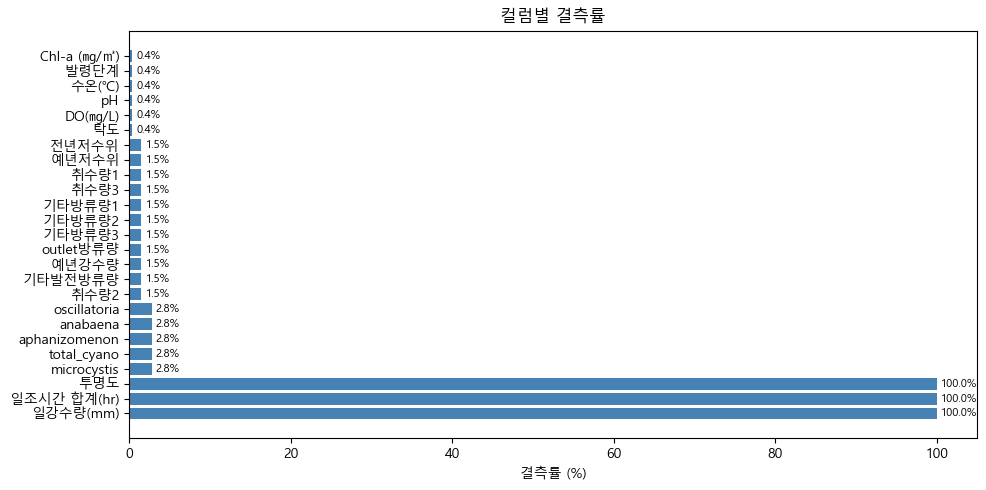

                결측 수  결측률(%)
일강수량(mm)       10959   100.0
일조시간 합계(hr)    10956   100.0
투명도            10956   100.0
microcystis      312     2.8
total_cyano      312     2.8
aphanizomenon    312     2.8
anabaena         312     2.8
oscillatoria     312     2.8
취수량2             162     1.5
기타발전방류량          162     1.5
예년강수량            162     1.5
outlet방류량        162     1.5
기타방류량3           162     1.5
기타방류량2           162     1.5
기타방류량1           162     1.5
취수량3             162     1.5
취수량1             162     1.5
예년저수위            162     1.5
전년저수위            162     1.5
탁도                39     0.4
DO(㎎/L)           39     0.4
pH                39     0.4
수온(℃)             39     0.4
발령단계              39     0.4
Chl-a (㎎/㎥)       39     0.4


In [3]:
miss = df_raw.isnull().sum()
miss_pct = (miss / len(df_raw) * 100).round(1)
miss_df = pd.DataFrame({'결측 수': miss, '결측률(%)': miss_pct})
miss_df = miss_df[miss_df['결측 수'] > 0].sort_values('결측률(%)', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(miss_df.index, miss_df['결측률(%)'], color='steelblue')
ax.set_xlabel('결측률 (%)')
ax.set_title('컬럼별 결측률')
for bar, pct in zip(bars, miss_df['결측률(%)']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{pct}%', va='center', fontsize=8)
plt.tight_layout(); plt.show()
print(miss_df)

### 1-2. 기초 통계

In [4]:
df_raw.select_dtypes(include='number').describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
total_cyano,10647.0,2092.04,7619.61,0.00,0.00,40.34,746.46,206126.00
microcystis,10647.0,1691.54,7142.93,0.00,0.00,0.00,330.33,205340.00
anabaena,10647.0,46.22,240.10,0.00,0.00,0.00,0.00,5614.00
oscillatoria,10647.0,131.19,692.54,0.00,0.00,0.00,0.00,16260.00
aphanizomenon,10647.0,154.66,1100.71,0.00,0.00,0.00,78.30,28732.00
일조시간 합계(hr),3.0,7.80,0.44,7.30,7.65,8.00,8.05,8.10
투명도,3.0,3.77,0.21,3.60,3.65,3.70,3.85,4.00
수온(℃),10920.0,15.36,7.09,3.30,8.70,15.07,21.99,29.90
pH,10920.0,7.88,0.53,5.90,7.53,7.80,8.20,10.90
DO(㎎/L),10920.0,8.99,2.64,1.80,6.84,9.26,11.26,13.70


## 2. 조류경보 발령 현황 분석

### 2-1. 발령단계 분포 (전체 / 지점별)

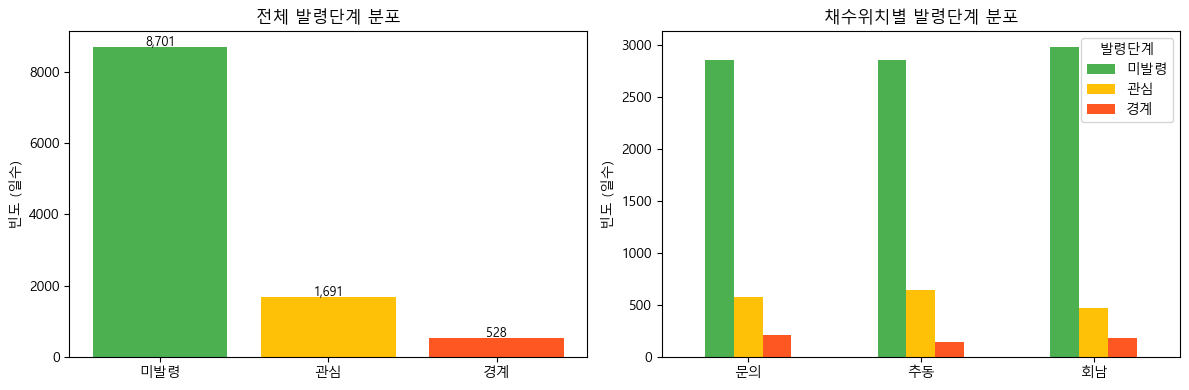

In [5]:
ALERT_ORDER  = ['미발령', '관심', '경계', '대발생']
ALERT_COLORS = {'미발령': '#4CAF50', '관심': '#FFC107', '경계': '#FF5722', '대발생': '#B71C1C'}

vc = (df_raw['발령단계'].value_counts()
      .reindex([a for a in ALERT_ORDER if a in df_raw['발령단계'].dropna().unique()]))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

bars = axes[0].bar(vc.index, vc.values,
                   color=[ALERT_COLORS.get(k, 'gray') for k in vc.index])
axes[0].set_title('전체 발령단계 분포')
axes[0].set_ylabel('빈도 (일수)')
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f'{int(bar.get_height()):,}', ha='center', fontsize=9)

site_alert = df_raw.groupby(['채수위치', '발령단계']).size().unstack(fill_value=0)
site_alert = site_alert[[c for c in ALERT_ORDER if c in site_alert.columns]]
site_alert.plot(kind='bar', ax=axes[1],
                color=[ALERT_COLORS.get(c, 'gray') for c in site_alert.columns])
axes[1].set_title('채수위치별 발령단계 분포')
axes[1].set_ylabel('빈도 (일수)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='발령단계')
plt.tight_layout(); plt.show()

### 2-2. 연도별 발령 추이

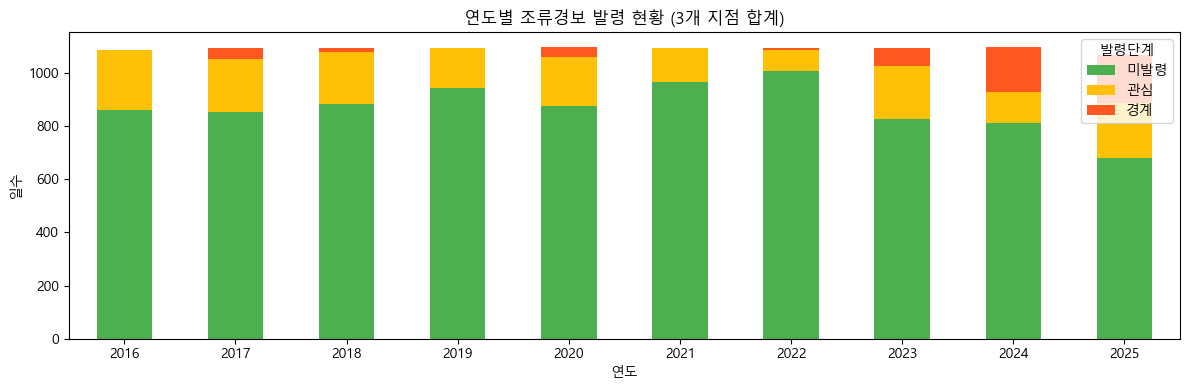

In [6]:
df_alert = df_raw[df_raw['발령단계'].notna()].copy()
df_alert['연도'] = df_alert['조사일'].dt.year
df_alert['월']   = df_alert['조사일'].dt.month
df_alert['발령여부'] = (df_alert['발령단계'] != '미발령').astype(int)

yearly = df_alert.groupby(['연도', '발령단계']).size().unstack(fill_value=0)
yearly = yearly[[c for c in ALERT_ORDER if c in yearly.columns]]
yearly.plot(kind='bar', stacked=True, figsize=(12, 4),
            color=[ALERT_COLORS.get(c, 'gray') for c in yearly.columns])
plt.title('연도별 조류경보 발령 현황 (3개 지점 합계)')
plt.xlabel('연도'); plt.ylabel('일수')
plt.xticks(rotation=0)
plt.legend(title='발령단계', loc='upper right')
plt.tight_layout(); plt.show()

### 2-3. 월별·계절별 발령 패턴

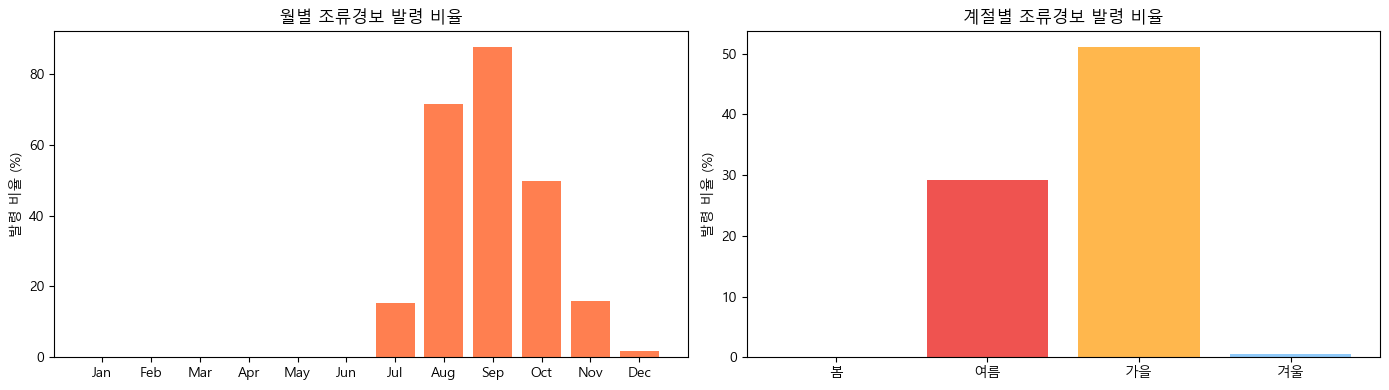

In [7]:
SEASON_MAP = {12:'겨울',1:'겨울',2:'겨울',
              3:'봄',4:'봄',5:'봄',
              6:'여름',7:'여름',8:'여름',
              9:'가을',10:'가을',11:'가을'}
df_alert['계절'] = df_alert['월'].map(SEASON_MAP)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

monthly = df_alert.groupby('월')['발령여부'].mean() * 100
axes[0].bar(monthly.index, monthly.values, color='coral')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                         'Jul','Aug','Sep','Oct','Nov','Dec'])
axes[0].set_ylabel('발령 비율 (%)')
axes[0].set_title('월별 조류경보 발령 비율')

season_order = ['봄', '여름', '가을', '겨울']
s_alert = df_alert.groupby('계절')['발령여부'].mean().reindex(season_order) * 100
axes[1].bar(season_order, s_alert.values,
            color=['#81C784','#EF5350','#FFB74D','#90CAF9'])
axes[1].set_ylabel('발령 비율 (%)')
axes[1].set_title('계절별 조류경보 발령 비율')
plt.tight_layout(); plt.show()

## 3. 유해남조류 세포 수 분석

### 3-1. log 변환 시계열 (지점 비교)

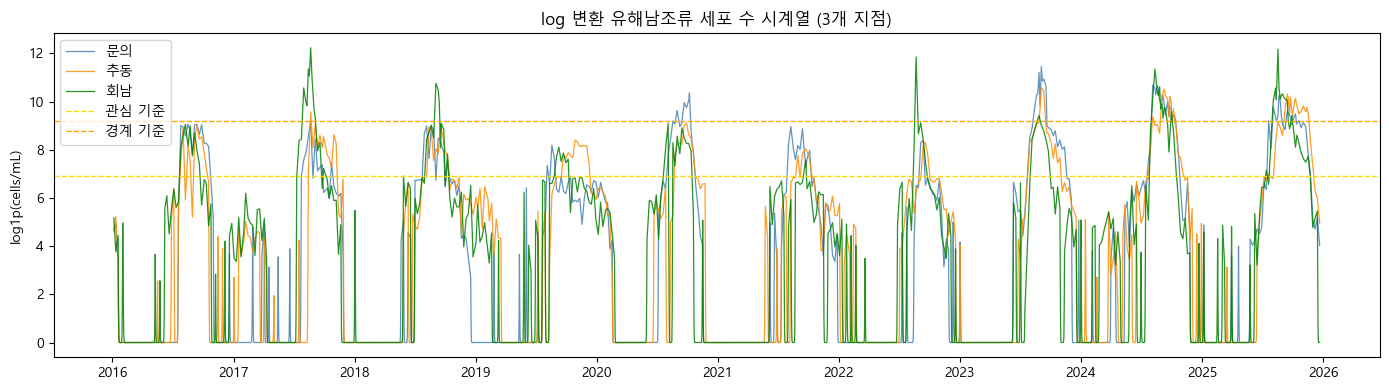

In [8]:
df_cyano = df_raw[df_raw['total_cyano'].notna()].copy()
df_cyano['log_cyano'] = np.log1p(df_cyano['total_cyano'])
df_cyano['month'] = df_cyano['조사일'].dt.month
df_cyano['year']  = df_cyano['조사일'].dt.year

SITE_COLORS = {'문의': 'steelblue', '추동': 'darkorange', '회남': 'green'}

plt.figure(figsize=(14, 4))
for site in df_cyano['채수위치'].unique():
    sub = df_cyano[df_cyano['채수위치'] == site].sort_values('조사일')
    plt.plot(sub['조사일'], sub['log_cyano'],
             label=site, color=SITE_COLORS.get(site, 'gray'), linewidth=0.9, alpha=0.85)
plt.axhline(np.log1p(1_000),  color='gold',   linestyle='--', linewidth=1, label='관심 기준')
plt.axhline(np.log1p(10_000), color='orange',  linestyle='--', linewidth=1, label='경계 기준')
plt.title('log 변환 유해남조류 세포 수 시계열 (3개 지점)')
plt.ylabel('log1p(cells/mL)')
plt.legend(loc='upper left')
plt.tight_layout(); plt.show()

### 3-2. 월별 조류 분포 (Boxplot)

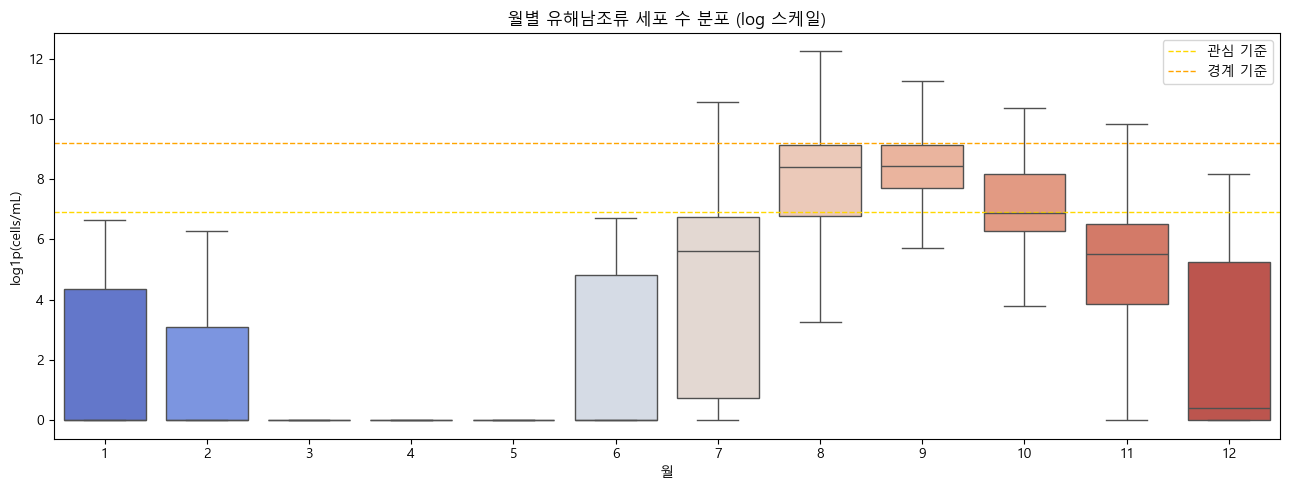

In [9]:
plt.figure(figsize=(13, 5))
sns.boxplot(
    data=df_cyano, x='month', y='log_cyano',
    palette='coolwarm', showfliers=False
)
plt.axhline(np.log1p(1_000),  color='gold',   linestyle='--', lw=1, label='관심 기준')
plt.axhline(np.log1p(10_000), color='orange',  linestyle='--', lw=1, label='경계 기준')
plt.title('월별 유해남조류 세포 수 분포 (log 스케일)')
plt.xlabel('월'); plt.ylabel('log1p(cells/mL)')
plt.legend(); plt.tight_layout(); plt.show()

### 3-3. 연도별 패턴 오버레이 (지점별)

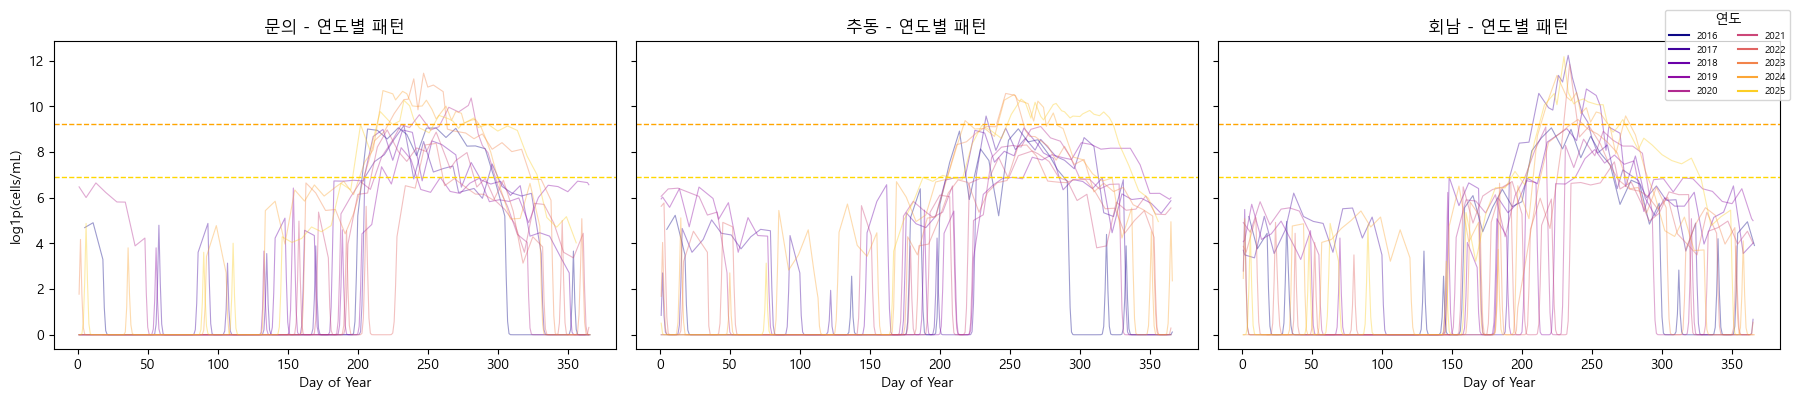

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)

for ax, site in zip(axes, ['문의', '추동', '회남']):
    if site not in df_cyano['채수위치'].unique():
        continue
    sub = df_cyano[df_cyano['채수위치'] == site]
    years = sorted(sub['year'].unique())
    cmap = plt.cm.plasma
    for i, y in enumerate(years):
        temp = sub[sub['year'] == y].sort_values('조사일')
        ax.plot(temp['조사일'].dt.dayofyear, temp['log_cyano'],
                alpha=0.4, linewidth=0.8,
                color=cmap(i / len(years)), label=str(y))
    ax.axhline(np.log1p(1_000),  color='gold',  linestyle='--', lw=1)
    ax.axhline(np.log1p(10_000), color='orange', linestyle='--', lw=1)
    ax.set_title(f'{site} - 연도별 패턴')
    ax.set_xlabel('Day of Year')

axes[0].set_ylabel('log1p(cells/mL)')

# 컬러바 대용 범례 (최근 연도만)
years_all = sorted(df_cyano['year'].unique())
cmap = plt.cm.plasma
handles = [plt.Line2D([0],[0], color=cmap(i/len(years_all)), lw=1.5, label=str(y))
           for i, y in enumerate(years_all)]
fig.legend(handles=handles, loc='upper right', ncol=2, fontsize=7,
           title='연도', bbox_to_anchor=(1.0, 1.0))
plt.tight_layout(); plt.show()

### 3-4. 발령 시 남조류 4종 구성

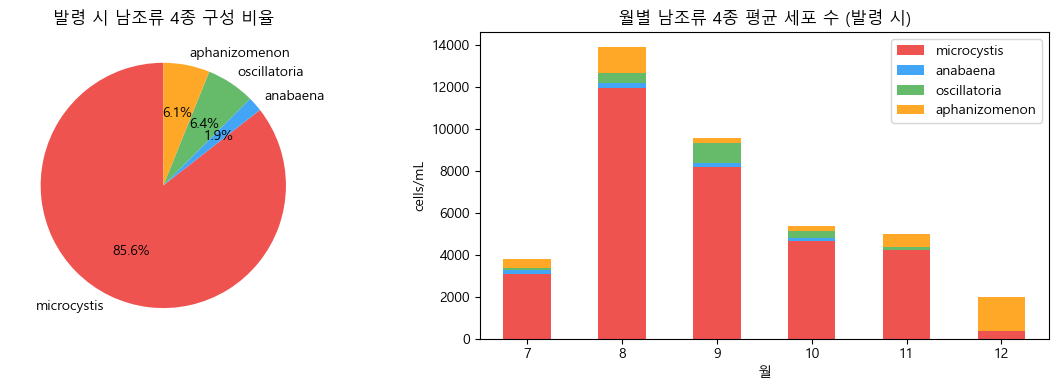

In [11]:
cyano_species = ['microcystis', 'anabaena', 'oscillatoria', 'aphanizomenon']
df_issued = df_cyano[df_cyano['발령단계'].isin(['관심', '경계'])]

sp_sum = df_issued[cyano_species].sum()
sp_pct = sp_sum / sp_sum.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sp_pct.plot(kind='pie', ax=axes[0], autopct='%1.1f%%',
            colors=['#EF5350','#42A5F5','#66BB6A','#FFA726'], startangle=90)
axes[0].set_title('발령 시 남조류 4종 구성 비율'); axes[0].set_ylabel('')

df_issued_m = df_issued.copy()
df_issued_m['월'] = df_issued_m['조사일'].dt.month
df_issued_m.groupby('월')[cyano_species].mean().plot(
    kind='bar', stacked=True, ax=axes[1],
    color=['#EF5350','#42A5F5','#66BB6A','#FFA726'])
axes[1].set_title('월별 남조류 4종 평균 세포 수 (발령 시)')
axes[1].set_xlabel('월'); axes[1].set_ylabel('cells/mL')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

## 4. 주요 영향 인자 분석

In [12]:
df_model_base = df_raw[df_raw['발령단계'].notna()].copy()
df_model_base['발령여부'] = (df_model_base['발령단계'] != '미발령').astype(int)

ENV_FEATURES = [
    '수온(℃)', 'pH', 'DO(㎎/L)', '탁도', 'Chl-a (㎎/㎥)',
    '평균기온(°C)', '평균 상대습도(%)', '합계 일조시간(hr)',
    '합계 일사량(MJ/m2)', '평균 전운량(1/10)',
    '수위(EL.m)', '저수율(%)', '유입량(㎥/s)', '강우량(mm)'
]
ENV_FEATURES = [f for f in ENV_FEATURES if f in df_model_base.columns]

### 4-1. 발령 여부에 따른 환경 변수 분포

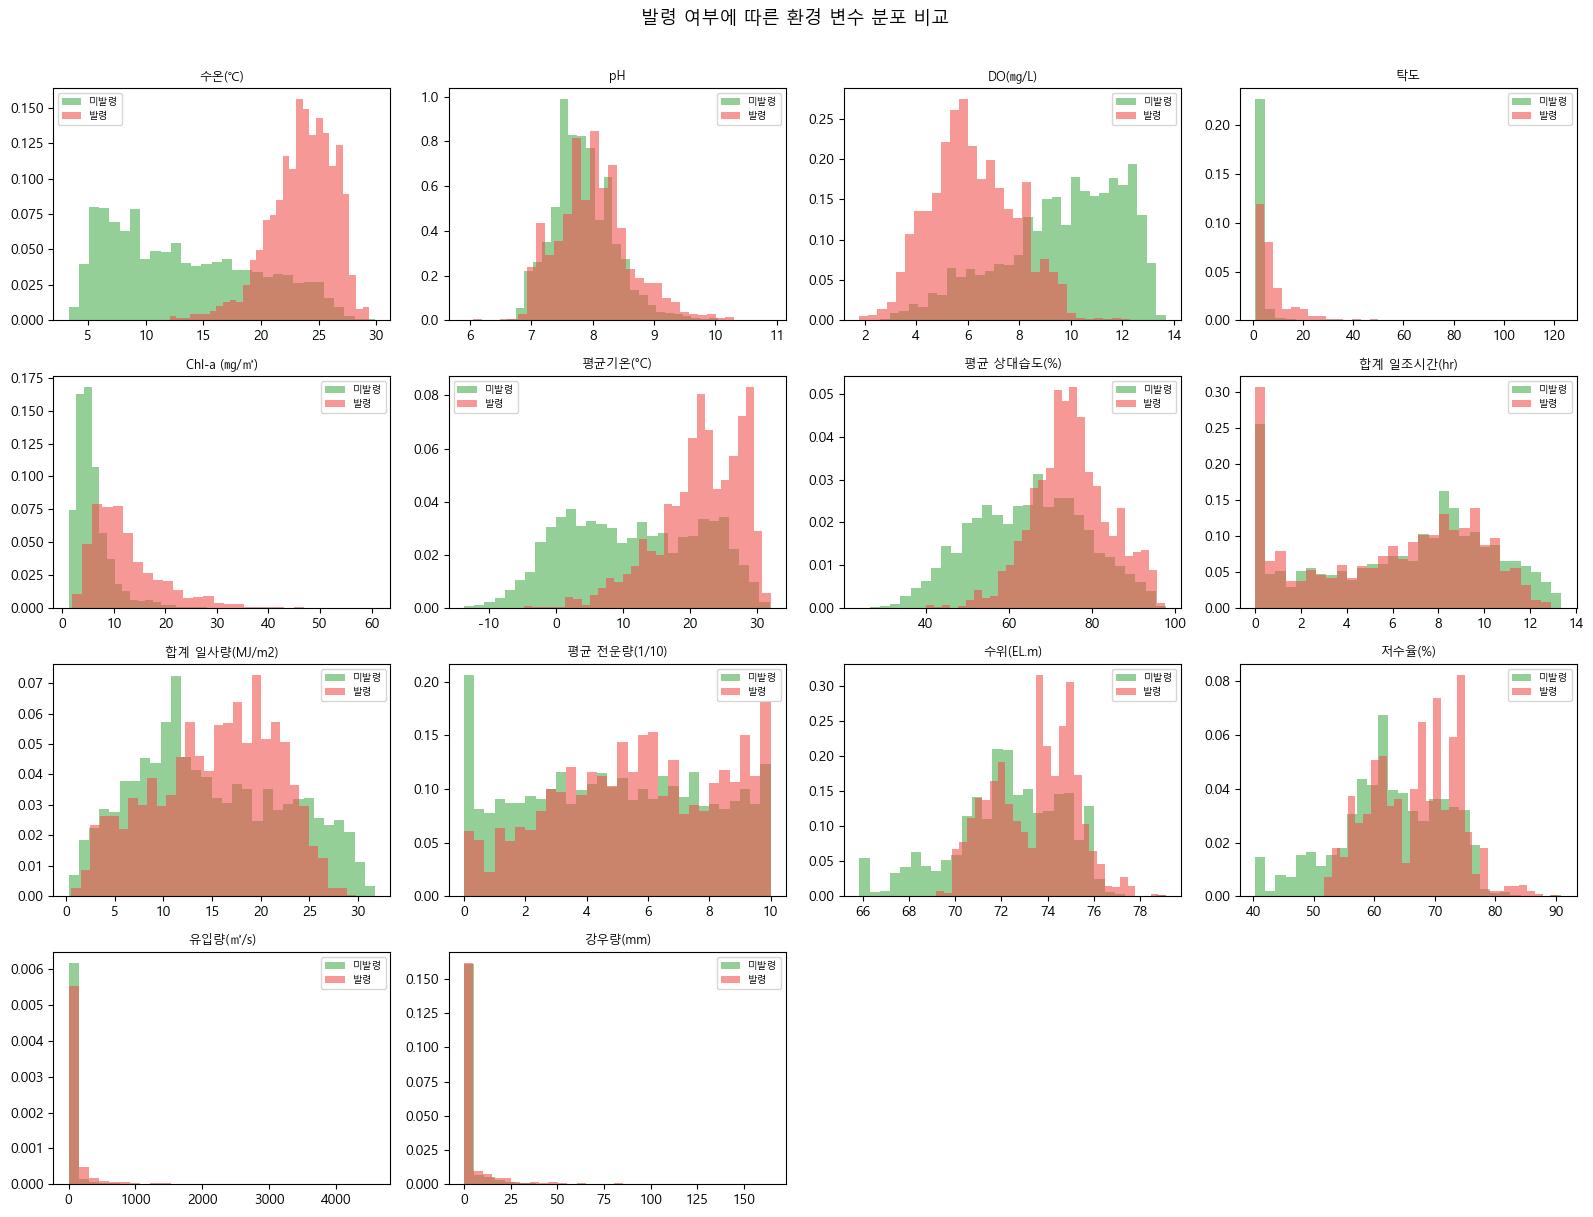

In [13]:
ncols = 4
nrows = (len(ENV_FEATURES) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3))
axes = axes.flatten()

for i, feat in enumerate(ENV_FEATURES):
    ax = axes[i]
    for label, color in [(0, '#4CAF50'), (1, '#EF5350')]:
        sub = df_model_base[df_model_base['발령여부'] == label][feat].dropna()
        ax.hist(sub, bins=30, alpha=0.6, color=color,
                label='미발령' if label == 0 else '발령', density=True)
    ax.set_title(feat, fontsize=9); ax.legend(fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('발령 여부에 따른 환경 변수 분포 비교', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

### 4-2. 상관관계 히트맵

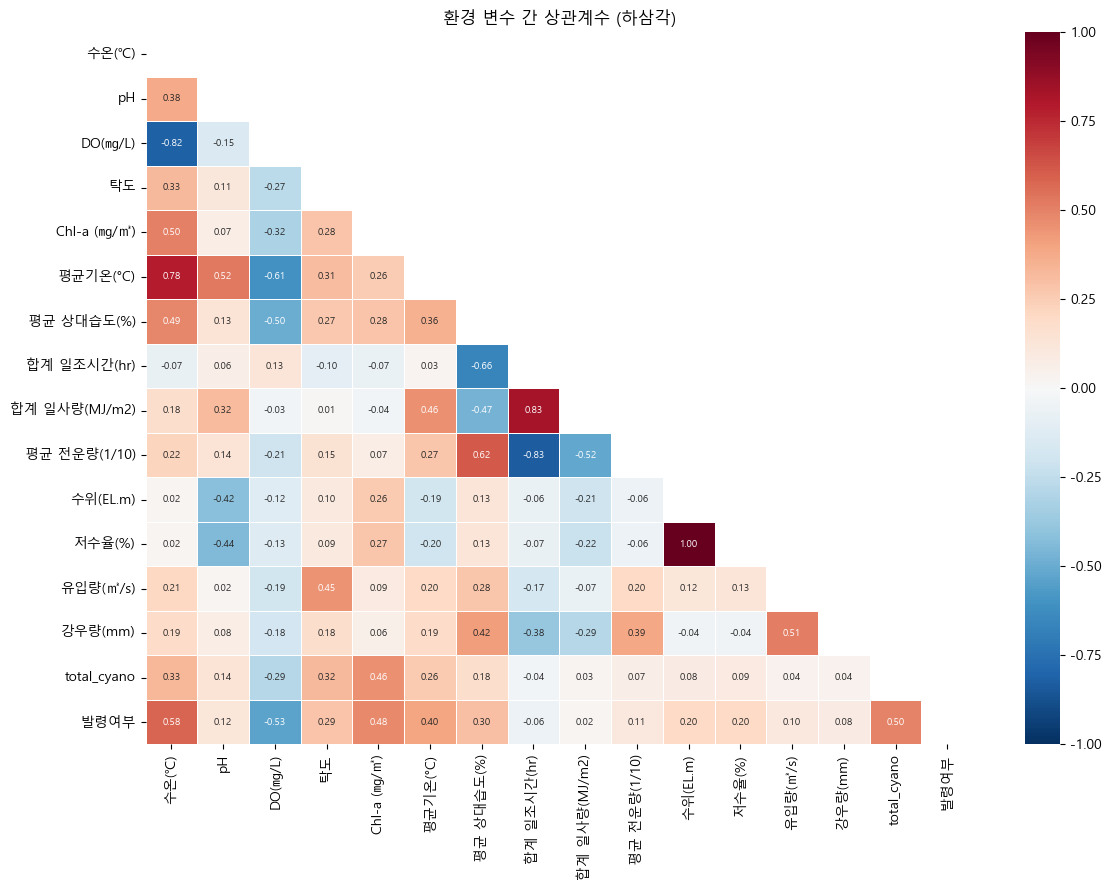

In [14]:
corr_cols = ENV_FEATURES + ['total_cyano', '발령여부']
corr_cols = [c for c in corr_cols if c in df_model_base.columns]
corr_m = df_model_base[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_m, dtype=bool))
sns.heatmap(corr_m, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax, annot_kws={'size': 7})
ax.set_title('환경 변수 간 상관계수 (하삼각)', fontsize=12)
plt.tight_layout(); plt.show()

### 4-3. 발령단계별 핵심 변수 Boxplot

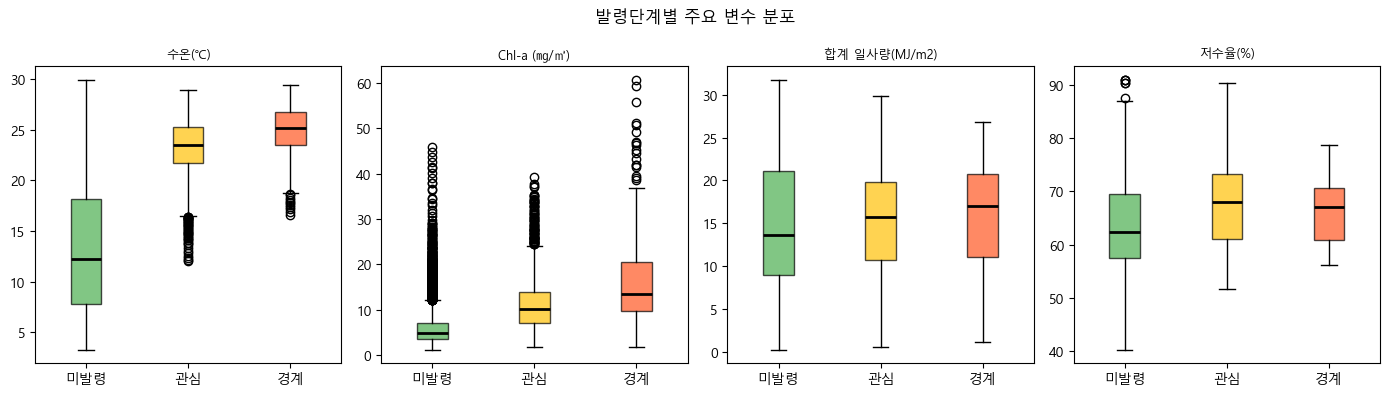

In [15]:
key_vars = ['수온(℃)', 'Chl-a (㎎/㎥)', '합계 일사량(MJ/m2)', '저수율(%)']
key_vars = [v for v in key_vars if v in df_model_base.columns]
alert_lvls = ['미발령', '관심', '경계']
df_bp = df_model_base[df_model_base['발령단계'].isin(alert_lvls)].copy()

fig, axes = plt.subplots(1, len(key_vars), figsize=(14, 4))
pal = {'미발령': '#4CAF50', '관심': '#FFC107', '경계': '#FF5722'}

for ax, col in zip(axes, key_vars):
    data = [df_bp[df_bp['발령단계'] == lvl][col].dropna() for lvl in alert_lvls]
    bp = ax.boxplot(data, labels=alert_lvls, patch_artist=True)
    for patch, lvl in zip(bp['boxes'], alert_lvls):
        patch.set_facecolor(pal[lvl]); patch.set_alpha(0.7)
    for med in bp['medians']:
        med.set(color='black', linewidth=2)
    ax.set_title(col, fontsize=9)

plt.suptitle('발령단계별 주요 변수 분포', fontsize=12)
plt.tight_layout(); plt.show()

## 5. 특성 공학 (Feature Engineering)

시계열 파생 특성을 추가하여 과거 환경 조건이 조류 발생에 미치는 누적 효과를 반영한다.

| 피처 유형 | 설명 |
|---|---|
| **Lag 피처** | t-7일, t-14일 시점의 환경 변수 값 |
| **Rolling 피처** | 직전 7일, 14일 이동 평균 (t-1일 기준) |
| **시간 피처** | 월(month), 주차(week) |
| **지점 인코딩** | 채수위치 Label Encoding |

In [16]:
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

df_ml = df_model_base.copy().sort_values(['채수위치', '조사일']).reset_index(drop=True)

# 시간 피처
df_ml['월']   = df_ml['조사일'].dt.month
df_ml['주차'] = df_ml['조사일'].dt.isocalendar().week.astype(int)

# 지점 인코딩
le = LabelEncoder()
df_ml['채수위치_enc'] = le.fit_transform(df_ml['채수위치'])

# Lag / Rolling 대상 피처
LAG_TARGETS = ['수온(℃)', '평균기온(°C)', '합계 일사량(MJ/m2)',
               '강우량(mm)', '저수율(%)', 'Chl-a (㎎/㎥)']
LAG_TARGETS = [f for f in LAG_TARGETS if f in df_ml.columns]

for feat in LAG_TARGETS:
    for lag in [7, 14]:
        df_ml[f'{feat}_lag{lag}'] = (
            df_ml.groupby('채수위치')[feat].shift(lag)
        )
    for window in [7, 14]:
        df_ml[f'{feat}_roll{window}'] = (
            df_ml.groupby('채수위치')[feat]
            .transform(lambda x: x.shift(1).rolling(window, min_periods=3).mean())
        )

print(f'기존 피처 수: {len(ENV_FEATURES) + 3}')
new_feats = [c for c in df_ml.columns
             if any(c.endswith(s) for s in ['_lag7','_lag14','_roll7','_roll14'])]
print(f'추가된 시계열 피처 수: {len(new_feats)}')
print(f'총 피처 수: {len(ENV_FEATURES) + 3 + len(new_feats)}')

기존 피처 수: 17
추가된 시계열 피처 수: 24
총 피처 수: 41


### 5-2. 학습 / 테스트 분할 (시계열 순서 유지)

In [17]:
EXCLUDE = [
    '조사일', '채수위치', '발령단계', '발령여부',
    'total_cyano', 'microcystis', 'anabaena', 'oscillatoria', 'aphanizomenon',
    '일조시간 합계(hr)', '투명도', '일강수량(mm)',
    '계절', '연도'
]
FEATURE_COLS = [c for c in df_ml.columns if c not in EXCLUDE]

df_sorted = df_ml.sort_values('조사일').reset_index(drop=True)

train_mask = df_sorted['조사일'] < '2024-01-01'
test_mask  = df_sorted['조사일'] >= '2024-01-01'

X_train = df_sorted.loc[train_mask, FEATURE_COLS]
X_test  = df_sorted.loc[test_mask,  FEATURE_COLS]
y_train = df_sorted.loc[train_mask, '발령여부']
y_test  = df_sorted.loc[test_mask,  '발령여부']

print(f'Train : {X_train.shape}  |  Test : {X_test.shape}')
print(f'Train 발령 비율: {y_train.mean():.1%}  |  Test 발령 비율: {y_test.mean():.1%}')

Train : (8754, 57)  |  Test : (2166, 57)
Train 발령 비율: 17.6%  |  Test 발령 비율: 31.2%


## 6. 다중 모델 비교 (Multi-Model Comparison)

이진 분류 (미발령 vs 발령)에서 4개 모델의 성능을 비교한다.

| 모델 | 주요 특징 |
|---|---|
| Logistic Regression | 선형 기준선 (baseline) |
| Decision Tree | 규칙 기반, 해석 용이 |
| Random Forest | 앙상블 — 과적합 강인 |
| Gradient Boosting | 순차 앙상블 — 높은 성능 |

In [18]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, roc_auc_score,
                              f1_score, precision_score, recall_score,
                              confusion_matrix, ConfusionMatrixDisplay, roc_curve)
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_sample_weight

MODELS = {
    'Logistic Regression': Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('scl', StandardScaler()),
        ('clf', LogisticRegression(class_weight='balanced',
                                   max_iter=1000, random_state=RANDOM_STATE))
    ]),
    'Decision Tree': Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('clf', DecisionTreeClassifier(max_depth=8, class_weight='balanced',
                                       random_state=RANDOM_STATE))
    ]),
    'Random Forest': Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('clf', RandomForestClassifier(n_estimators=300, max_depth=12,
                                       min_samples_leaf=5,
                                       class_weight='balanced',
                                       random_state=RANDOM_STATE, n_jobs=-1))
    ]),
    'Gradient Boosting': Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('clf', GradientBoostingClassifier(n_estimators=300, max_depth=5,
                                           learning_rate=0.05,
                                           subsample=0.8,
                                           random_state=RANDOM_STATE))
    ]),
}

results = {}
fitted  = {}

for name, pipe in MODELS.items():
    print(f'Training {name} ...')
    # GBM 은 class_weight 미지원 -> sample_weight 사용
    if name == 'Gradient Boosting':
        sw = compute_sample_weight('balanced', y_train)
        pipe.fit(X_train, y_train, clf__sample_weight=sw)
    else:
        pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    results[name] = {
        'F1 (macro)':   f1_score(y_test, y_pred, average='macro'),
        'F1 (발령)':    f1_score(y_test, y_pred, pos_label=1),
        'Precision (발령)': precision_score(y_test, y_pred, pos_label=1, zero_division=0),
        'Recall (발령)':    recall_score(y_test, y_pred, pos_label=1),
        'ROC-AUC':      roc_auc_score(y_test, y_prob),
    }
    fitted[name] = pipe

results_df = pd.DataFrame(results).T.round(4)
print('\n=== 모델 성능 비교 ===')
print(results_df.sort_values('ROC-AUC', ascending=False))

Training Logistic Regression ...
Training Decision Tree ...
Training Random Forest ...
Training Gradient Boosting ...

=== 모델 성능 비교 ===
                     F1 (macro)  F1 (발령)  Precision (발령)  Recall (발령)  ROC-AUC
Random Forest            0.8954   0.8485          0.9750       0.7511   0.9894
Gradient Boosting        0.8498   0.7766          0.9908       0.6385   0.9839
Logistic Regression      0.9055   0.8666          0.9215       0.8178   0.9818
Decision Tree            0.9015   0.8588          0.9564       0.7793   0.8888


### 6-1. 성능 비교 차트

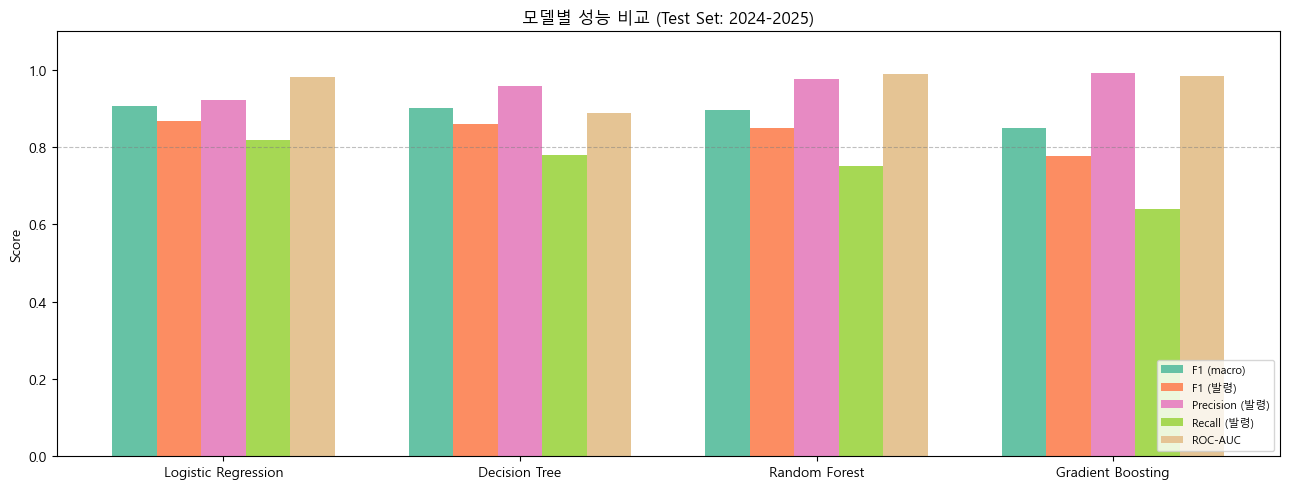

In [19]:
metrics = ['F1 (macro)', 'F1 (발령)', 'Precision (발령)', 'Recall (발령)', 'ROC-AUC']
n_metrics = len(metrics)
x = np.arange(len(results_df))
width = 0.15

fig, ax = plt.subplots(figsize=(13, 5))
cmap = plt.cm.Set2
for i, metric in enumerate(metrics):
    bars = ax.bar(x + i * width, results_df[metric],
                  width, label=metric, color=cmap(i / n_metrics))

ax.set_xticks(x + width * (n_metrics - 1) / 2)
ax.set_xticklabels(results_df.index, fontsize=10)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('모델별 성능 비교 (Test Set: 2024-2025)')
ax.legend(loc='lower right', fontsize=8)
ax.axhline(0.8, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
plt.tight_layout(); plt.show()

### 6-2. ROC Curve 비교

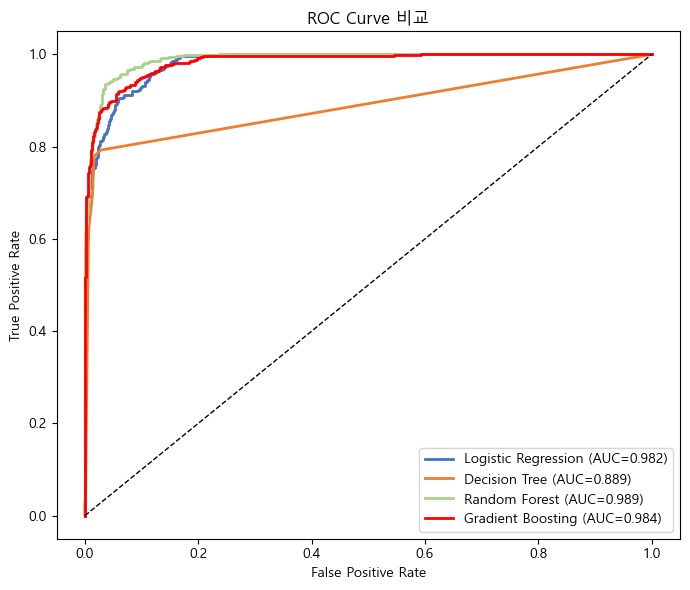

Best model: Random Forest


In [20]:
fig, ax = plt.subplots(figsize=(7, 6))
colors = ['#4472C4', '#ED7D31', '#A9D18E', '#FF0000']

for (name, pipe), color in zip(fitted.items(), colors):
    y_prob = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, lw=2, color=color, label=f'{name} (AUC={auc:.3f})')

ax.plot([0,1],[0,1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve 비교')
ax.legend(loc='lower right')
plt.tight_layout(); plt.show()

# 최적 모델 선정
BEST_MODEL_NAME = results_df['ROC-AUC'].idxmax()
BEST_PIPE = fitted[BEST_MODEL_NAME]
print(f'Best model: {BEST_MODEL_NAME}')

### 6-3. 다중 분류 (미발령 / 관심 / 경계) — Random Forest

=== 3-class 분류 리포트 (Test Set) ===
              precision    recall  f1-score   support

         미발령       0.92      0.98      0.95      1491
          관심       0.36      0.63      0.46       322
          경계       1.00      0.01      0.02       353

    accuracy                           0.77      2166
   macro avg       0.76      0.54      0.48      2166
weighted avg       0.85      0.77      0.72      2166



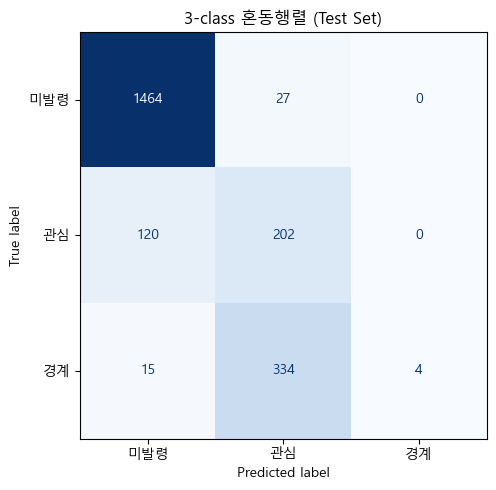

In [21]:
alert_map = {'미발령': 0, '관심': 1, '경계': 2}
df_3c = df_sorted[df_sorted['발령단계'].isin(alert_map.keys())].copy()
df_3c['타겟'] = df_3c['발령단계'].map(alert_map)

tr3 = df_3c['조사일'] < '2024-01-01'
te3 = df_3c['조사일'] >= '2024-01-01'

rf3 = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('clf', RandomForestClassifier(n_estimators=300, max_depth=12,
                                   min_samples_leaf=5, class_weight='balanced',
                                   random_state=RANDOM_STATE, n_jobs=-1))
])
rf3.fit(df_3c.loc[tr3, FEATURE_COLS], df_3c.loc[tr3, '타겟'])
pred3 = rf3.predict(df_3c.loc[te3, FEATURE_COLS])

print('=== 3-class 분류 리포트 (Test Set) ===')
print(classification_report(df_3c.loc[te3, '타겟'], pred3,
                             target_names=['미발령', '관심', '경계']))

cm3 = confusion_matrix(df_3c.loc[te3, '타겟'], pred3)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm3, display_labels=['미발령', '관심', '경계']).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title('3-class 혼동행렬 (Test Set)')
plt.tight_layout(); plt.show()

## 7. SHAP Value 분석

SHAP(SHapley Additive exPlanations)은 각 피처가 개별 예측에 기여하는 정도를 정량화한다. MDI(Mean Decrease Impurity) 기반 Feature Importance와 달리 **데이터 편향에 강인**하고 **개별 예측 설명**이 가능하다.

| Plot 유형 | 설명 |
|---|---|
| Summary Bar | 전체 평균 |SHAP| — 전역적 중요도 순위 |
| Beeswarm | 개별 샘플의 SHAP 값 분포 — 방향성·크기 동시 확인 |
| Dependence | 특정 피처 값과 SHAP 기여도의 관계 |

In [32]:
if not SHAP_OK:
    print('[SKIP] shap 미설치. pip install shap 후 재실행하세요.')
else:
    # TreeExplainer는 트리 기반 모델 전용 → Random Forest 고정 사용
    rf_pipe   = fitted['Random Forest']
    imp_step  = rf_pipe.named_steps['imp']
    rf_clf    = rf_pipe.named_steps['clf']

    X_test_imp = pd.DataFrame(
        imp_step.transform(X_test),
        columns=FEATURE_COLS
    )

    explainer = shap.TreeExplainer(rf_clf)
    shap_vals = explainer.shap_values(X_test_imp)

    # 이진 RF → list[2]: index 1 = 발령(class 1) 기여도
    sv = shap_vals[1] if isinstance(shap_vals, list) else shap_vals

    print(f'SHAP values: {sv.shape}  (samples x features)')
    print(f'피처 수: {len(FEATURE_COLS)}')

SHAP values: (2166, 57, 2)  (samples x features)
피처 수: 57


### 7-1. SHAP Summary Plot (Bar) — 전역적 피처 중요도

<Figure size 640x480 with 0 Axes>

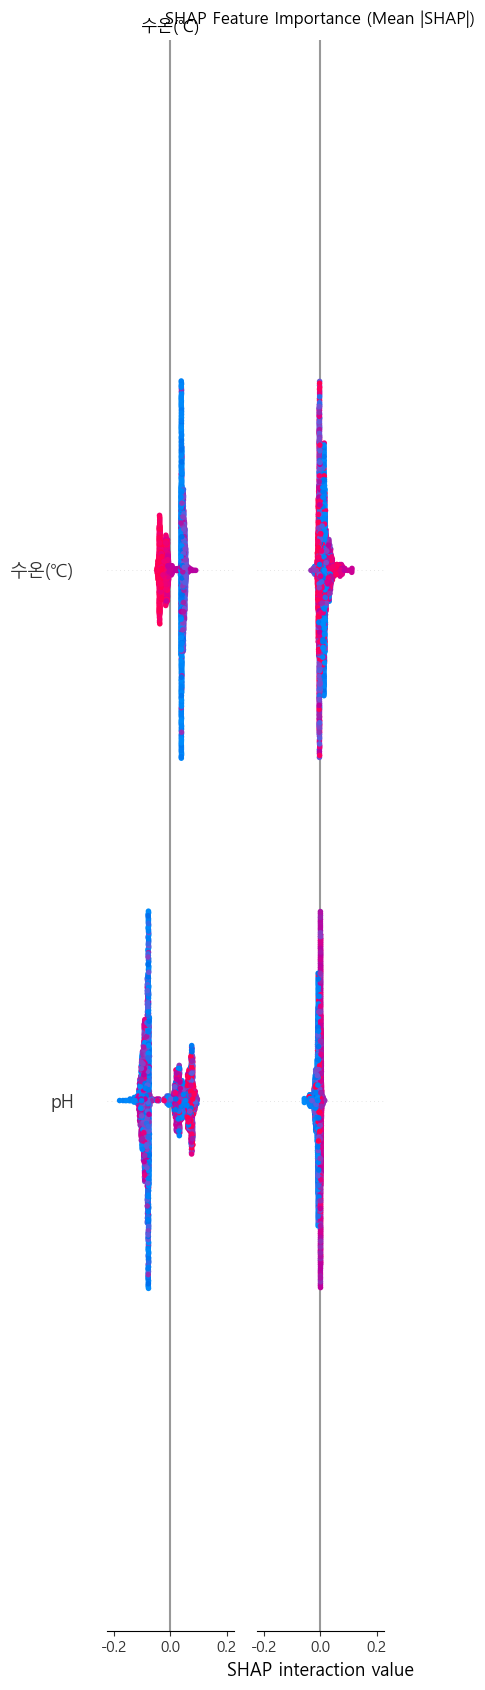

In [33]:
if SHAP_OK:
    plt.figure()
    shap.summary_plot(
        sv, X_test_imp,
        feature_names=FEATURE_COLS,
        plot_type='bar',
        max_display=20,
        show=False          # show=False 로 matplotlib 제어권 유지
    )
    plt.title('SHAP Feature Importance (Mean |SHAP|)', pad=12)
    plt.tight_layout()
    plt.show()

### 7-2. SHAP Beeswarm Plot — 방향성 및 개별 샘플 기여도

<Figure size 640x480 with 0 Axes>

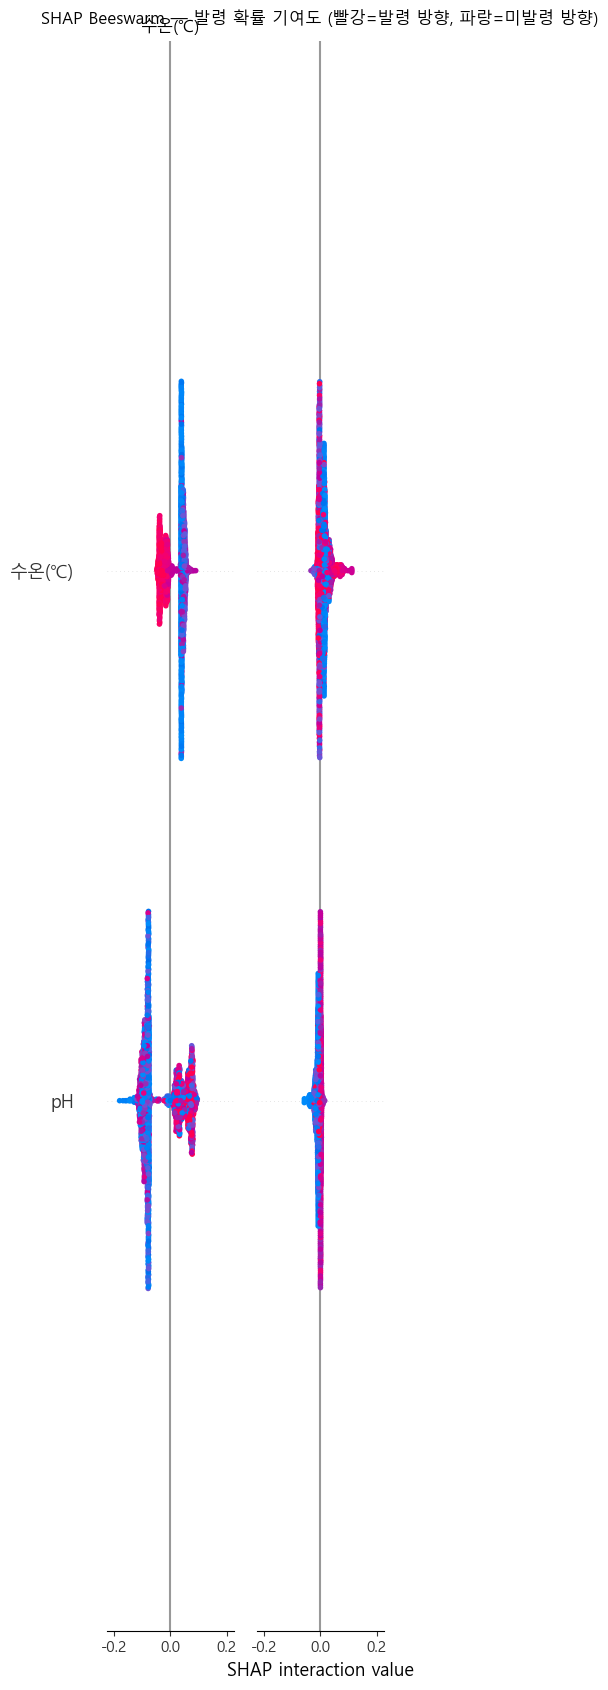

ValueError: Data must be 1-dimensional, got ndarray of shape (57, 2) instead

In [34]:
if SHAP_OK:
    plt.figure()
    shap.summary_plot(
        sv, X_test_imp,
        feature_names=FEATURE_COLS,
        max_display=20,
        show=False
    )
    plt.title('SHAP Beeswarm — 발령 확률 기여도 (빨강=발령 방향, 파랑=미발령 방향)', pad=12)
    plt.tight_layout()
    plt.show()

    # 해석 요약 출력
    mean_abs = pd.Series(np.abs(sv).mean(axis=0), index=FEATURE_COLS)
    print('\n=== 상위 10개 SHAP 인자 (Mean |SHAP|) ===')
    for rank, (name, val) in enumerate(mean_abs.sort_values(ascending=False).head(10).items(), 1):
        print(f'  {rank:2d}. {name:35s}  {val:.5f}')

### 7-3. SHAP Dependence Plot — 핵심 인자별 비선형 효과

각 인자의 **값 변화에 따른 SHAP 기여도 변화**와 상호작용 효과를 보여준다.

In [35]:
if SHAP_OK:
    mean_abs_shap = np.abs(sv).mean(axis=0)
    top5_idx   = np.argsort(mean_abs_shap)[::-1][:5]
    top5_feats = [FEATURE_COLS[i] for i in top5_idx]

    for feat in top5_feats:
        plt.figure(figsize=(7, 4))
        shap.dependence_plot(
            feat,
            sv,
            X_test_imp,
            feature_names=FEATURE_COLS,
            show=False
        )
        plt.title(f'SHAP Dependence: {feat}', pad=10)
        plt.tight_layout()
        plt.show()

TypeError: only integer scalar arrays can be converted to a scalar index

### 7-4. SHAP Waterfall Plot — 개별 예측 설명 (발령 사례)

실제 발령이 있었던 샘플 1개에 대해 각 피처의 기여도를 설명한다.

In [36]:
if SHAP_OK:
    # 발령(y=1) 샘플 중 예측 확률이 가장 높은 케이스 선택
    y_test_arr = y_test.values
    rf_probs   = rf_pipe.predict_proba(X_test)[:, 1]
    alert_idxs = np.where(y_test_arr == 1)[0]
    sample_idx = alert_idxs[np.argmax(rf_probs[alert_idxs])]

    plt.figure()
    shap.waterfall_plot(
        shap.Explanation(
            values=sv[sample_idx],
            base_values=explainer.expected_value[1] if isinstance(explainer.expected_value, list)
                        else explainer.expected_value,
            data=X_test_imp.iloc[sample_idx],
            feature_names=FEATURE_COLS
        ),
        max_display=15,
        show=False
    )
    plt.title('SHAP Waterfall — 발령 확률 최고 샘플 피처 기여도', pad=12)
    plt.tight_layout()
    plt.show()

ValueError: The waterfall plot can currently only plot a single explanation, but a matrix of explanations (shape (57, 2)) was passed! Perhaps try `shap.plots.waterfall(shap_values[0])` or for multi-output models, try `shap.plots.waterfall(shap_values[0, 0])`.

<Figure size 640x480 with 0 Axes>

## 8. 선행 예측 프레임 (Lead-time Prediction)

현재 측정된 환경 조건으로 **N일 후 조류경보 발령 여부**를 예측한다.

```
[t 시점 피처] → 모델 → [t+N 발령 여부 예측]
```

목표 변수를 N일 앞으로 shift하여 구성한다.

In [26]:
def make_lead_dataset(df_sorted, feature_cols, lead_days):
    """lead_days 후 발령여부를 타겟으로 하는 데이터셋 생성."""
    df_lead = df_sorted.copy()
    df_lead[f'target_lead{lead_days}'] = (
        df_lead.groupby('채수위치')['발령여부'].shift(-lead_days)
    )
    df_lead = df_lead.dropna(subset=[f'target_lead{lead_days}'])
    df_lead[f'target_lead{lead_days}'] = df_lead[f'target_lead{lead_days}'].astype(int)
    return df_lead

lead_results = {}

for lead in [7, 14]:
    df_lead = make_lead_dataset(df_sorted, FEATURE_COLS, lead)
    tr_m = df_lead['조사일'] < '2024-01-01'
    te_m = df_lead['조사일'] >= '2024-01-01'

    Xl_tr = df_lead.loc[tr_m, FEATURE_COLS]
    Xl_te = df_lead.loc[te_m, FEATURE_COLS]
    yl_tr = df_lead.loc[tr_m, f'target_lead{lead}']
    yl_te = df_lead.loc[te_m, f'target_lead{lead}']

    pipe_lead = Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('clf', RandomForestClassifier(n_estimators=300, max_depth=10,
                                       min_samples_leaf=5, class_weight='balanced',
                                       random_state=RANDOM_STATE, n_jobs=-1))
    ])
    pipe_lead.fit(Xl_tr, yl_tr)
    yp = pipe_lead.predict(Xl_te)
    yprob = pipe_lead.predict_proba(Xl_te)[:, 1]

    lead_results[f't+{lead}d'] = {
        'F1 (발령)': f1_score(yl_te, yp, pos_label=1),
        'Recall (발령)': recall_score(yl_te, yp, pos_label=1),
        'Precision (발령)': precision_score(yl_te, yp, pos_label=1, zero_division=0),
        'ROC-AUC':   roc_auc_score(yl_te, yprob),
    }

    print(f'\n=== 선행 {lead}일 예측 리포트 ===')
    print(classification_report(yl_te, yp, target_names=['미발령', '발령']))

print('\n=== Lead-time 성능 비교 ===')
print(pd.DataFrame(lead_results).T.round(4))


=== 선행 7일 예측 리포트 ===
              precision    recall  f1-score   support

         미발령       0.92      0.98      0.95      1470
          발령       0.96      0.81      0.88       675

    accuracy                           0.93      2145
   macro avg       0.94      0.90      0.91      2145
weighted avg       0.93      0.93      0.93      2145


=== 선행 14일 예측 리포트 ===
              precision    recall  f1-score   support

         미발령       0.91      0.99      0.95      1449
          발령       0.98      0.79      0.87       675

    accuracy                           0.93      2124
   macro avg       0.94      0.89      0.91      2124
weighted avg       0.93      0.93      0.92      2124


=== Lead-time 성능 비교 ===
       F1 (발령)  Recall (발령)  Precision (발령)  ROC-AUC
t+7d    0.8771       0.8089          0.9579   0.9879
t+14d   0.8721       0.7881          0.9761   0.9917


### 8-1. 선행 예측 성능 비교 (t+0 vs t+7 vs t+14)

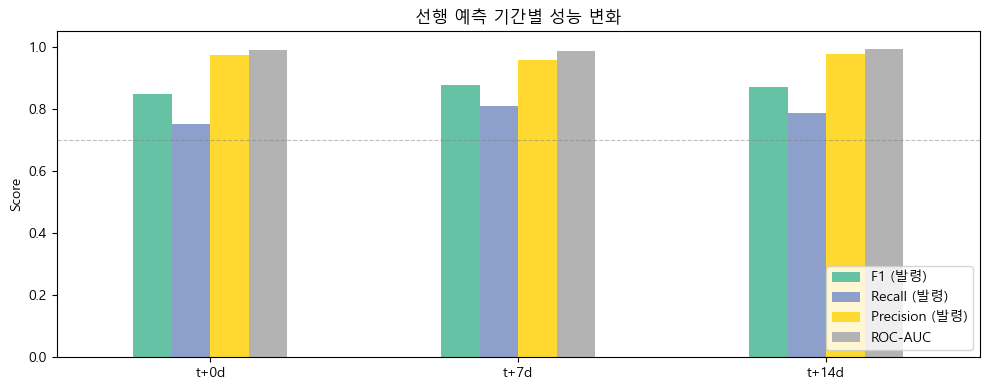

       F1 (발령)  Recall (발령)  Precision (발령)  ROC-AUC
t+0d    0.8485       0.7511          0.9750   0.9894
t+7d    0.8771       0.8089          0.9579   0.9879
t+14d   0.8721       0.7881          0.9761   0.9917


In [27]:
# t+0 (현재 예측) 성능 추가
best_prob = BEST_PIPE.predict_proba(X_test)[:, 1]
best_pred = BEST_PIPE.predict(X_test)
lead_results['t+0d'] = {
    'F1 (발령)': f1_score(y_test, best_pred, pos_label=1),
    'Recall (발령)': recall_score(y_test, best_pred, pos_label=1),
    'Precision (발령)': precision_score(y_test, best_pred, pos_label=1, zero_division=0),
    'ROC-AUC':   roc_auc_score(y_test, best_prob),
}

lead_df = pd.DataFrame(lead_results).T.reindex(['t+0d', 't+7d', 't+14d'])

lead_df.plot(kind='bar', figsize=(10, 4), colormap='Set2')
plt.title('선행 예측 기간별 성능 변화')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0, 1.05)
plt.axhline(0.7, color='gray', linestyle='--', lw=0.8, alpha=0.5)
plt.legend(loc='lower right')
plt.tight_layout(); plt.show()

print(lead_df.round(4))

## 9. 딥러닝 — LSTM

LSTM(Long Short-Term Memory)은 순서 정보를 학습하는 RNN 계열 모델로,
과거 30일 환경 데이터 시퀀스에서 당일 조류경보 발령 여부를 예측한다.

| 설정 | 내용 |
|---|---|
| 시퀀스 길이 | 30일 (30-day window) |
| 지점 | 문의 (단일 지점) |
| 분할 | 2016-2022 train / 2023 val / 2024-2025 test |
| 구조 | LSTM(64) → Dropout(0.3) → Dense(32) → Dense(1, sigmoid) |

In [28]:
if not TF_OK:
    print('[SKIP] tensorflow 미설치. pip install tensorflow 후 재실행하세요.')
else:
    from sklearn.preprocessing import StandardScaler

    SEQ_LEN = 30
    SITE    = '문의'

    # 단일 지점 데이터 추출 & 정렬
    df_lstm = df_sorted[df_sorted['채수위치'] == SITE].sort_values('조사일').copy()

    # 결측 보간 (median imputation)
    imp_lstm = SimpleImputer(strategy='median')
    X_lstm_arr = imp_lstm.fit_transform(df_lstm[FEATURE_COLS])
    y_lstm_arr = df_lstm['발령여부'].values.astype(np.float32)

    # 정규화
    scaler = StandardScaler()
    X_lstm_scaled = scaler.fit_transform(X_lstm_arr)

    # 시퀀스 생성
    def make_sequences(X, y, seq_len):
        Xs, ys = [], []
        for i in range(len(X) - seq_len):
            Xs.append(X[i:i+seq_len])
            ys.append(y[i+seq_len])
        return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32)

    X_seq, y_seq = make_sequences(X_lstm_scaled, y_lstm_arr, SEQ_LEN)

    # 날짜 기반 분할
    dates = df_lstm['조사일'].values[SEQ_LEN:]
    tr_idx = dates <  np.datetime64('2023-01-01')
    va_idx = (dates >= np.datetime64('2023-01-01')) & (dates < np.datetime64('2024-01-01'))
    te_idx = dates >= np.datetime64('2024-01-01')

    X_tr, y_tr = X_seq[tr_idx], y_seq[tr_idx]
    X_va, y_va = X_seq[va_idx], y_seq[va_idx]
    X_te, y_te = X_seq[te_idx], y_seq[te_idx]

    print(f'Sequences  - train:{X_tr.shape}, val:{X_va.shape}, test:{X_te.shape}')
    print(f'Train 발령 비율: {y_tr.mean():.1%}  |  Test: {y_te.mean():.1%}')

Sequences  - train:(2523, 30, 57), val:(365, 30, 57), test:(722, 30, 57)
Train 발령 비율: 17.5%  |  Test: 31.9%


### 9-1. LSTM 모델 구성 및 학습

In [29]:
if TF_OK:
    tf.random.set_seed(RANDOM_STATE)

    n_features = X_tr.shape[2]

    # 불균형 보정
    pos_count = int(y_tr.sum())
    neg_count = len(y_tr) - pos_count
    pos_weight = neg_count / pos_count

    model = keras.Sequential([
        keras.layers.Input(shape=(SEQ_LEN, n_features)),
        keras.layers.LSTM(64, return_sequences=False),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(32, activation='relu'),
        keras.layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss='binary_crossentropy',
        metrics=[keras.metrics.AUC(name='auc')]
    )
    model.summary()

    callbacks = [
        keras.callbacks.EarlyStopping(monitor='val_auc', patience=10,
                                      restore_best_weights=True, mode='max'),
        keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                          patience=5, verbose=0)
    ]

    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_va, y_va),
        epochs=60,
        batch_size=64,
        class_weight={0: 1.0, 1: pos_weight},
        callbacks=callbacks,
        verbose=1
    )

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        31,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,345 (130.25 KB)

 Trainable params: 33,345 (130.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - auc: 0.9519 - loss: 0.5706 - val_auc: 0.9514 - val_loss: 0.3259 - learning_rate: 0.0010
Epoch 2/60
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - auc: 0.9921 - loss: 0.1991 - val_auc: 0.9535 - val_loss: 0.4299 - learning_rate: 0.0010
Epoch 3/60
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - auc: 0.9954 - loss: 0.1379 - val_auc: 0.9517 - val_loss: 0.5451 - learning_rate: 0.0010
Epoch 4/60
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - auc: 0.9972 - loss: 0.1073 - val_auc: 0.9193 - val_loss: 0.6556 - learning_rate: 0.0010
Epoch 5/60
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - auc: 0.9980 - loss: 0.0810 - val_auc: 0.8476 - val_loss: 0.7601 - learning_rate: 0.0010
Epoch 6/60
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - auc: 0.9982 - loss: 0.0768 - val_auc: 0.8091 - val_loss: 0.8933 - learning_rate: 0.0010
Epoch 7/60
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - auc: 0.9984 - loss: 0.0742 - val_auc: 0.8066 - val_loss: 0.9395 - learning_rate: 5.0000e-04
Epoch 8/60
40/4

### 9-2. 학습 곡선 및 평가

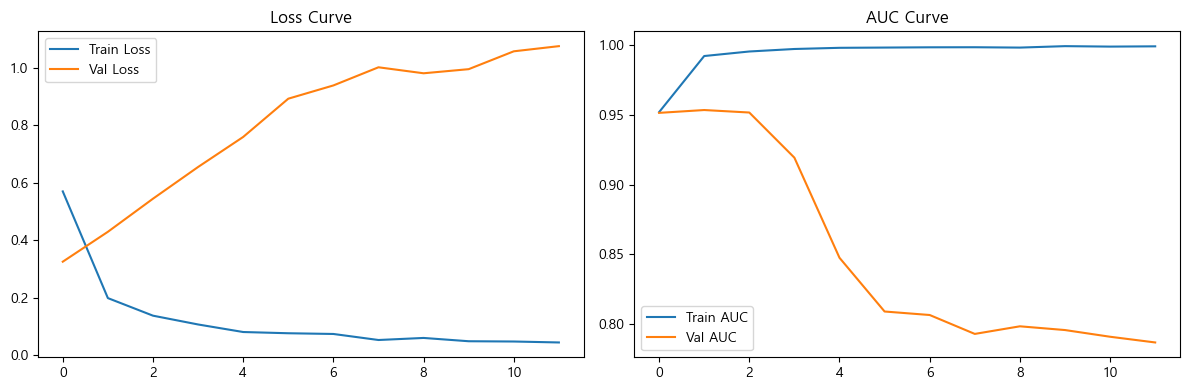

=== LSTM 분류 리포트 (Test: 2024-2025) ===
              precision    recall  f1-score   support

         미발령       0.90      0.99      0.94       492
          발령       0.97      0.75      0.85       230

    accuracy                           0.91       722
   macro avg       0.93      0.87      0.89       722
weighted avg       0.92      0.91      0.91       722

ROC-AUC: 0.9885


In [30]:
if TF_OK:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history.history['loss'],     label='Train Loss')
    axes[0].plot(history.history['val_loss'],  label='Val Loss')
    axes[0].set_title('Loss Curve'); axes[0].legend()

    axes[1].plot(history.history['auc'],      label='Train AUC')
    axes[1].plot(history.history['val_auc'],   label='Val AUC')
    axes[1].set_title('AUC Curve'); axes[1].legend()

    plt.tight_layout(); plt.show()

    # Test 평가
    y_lstm_prob = model.predict(X_te, verbose=0).ravel()
    y_lstm_pred = (y_lstm_prob >= 0.5).astype(int)

    print('=== LSTM 분류 리포트 (Test: 2024-2025) ===')
    print(classification_report(y_te, y_lstm_pred, target_names=['미발령', '발령']))
    print(f'ROC-AUC: {roc_auc_score(y_te, y_lstm_prob):.4f}')

### 9-3. LSTM 예측 결과 시각화

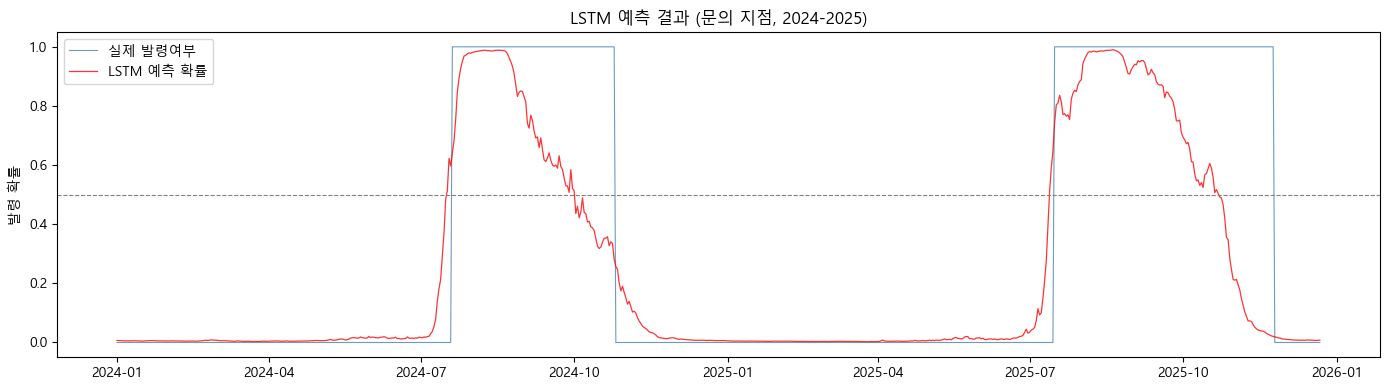

In [31]:
if TF_OK:
    test_dates = dates[te_idx]

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(test_dates, y_te,         color='steelblue', lw=0.8,
            label='실제 발령여부', alpha=0.8)
    ax.plot(test_dates, y_lstm_prob,  color='red', lw=0.9,
            label='LSTM 예측 확률', alpha=0.8)
    ax.axhline(0.5, color='gray', linestyle='--', lw=0.8)
    ax.set_ylabel('발령 확률')
    ax.set_title(f'LSTM 예측 결과 ({SITE} 지점, 2024-2025)')
    ax.legend()
    plt.tight_layout(); plt.show()

## 10. 결과 요약 및 의사결정 지원 시사점

### 10-1. 모델 성능 종합

| 모델 | 특성 | 장점 | 단점 |
|---|---|---|---|
| Logistic Regression | 선형 기준선 | 빠름, 해석 쉬움 | 비선형 패턴 미반영 |
| Decision Tree | 규칙 기반 | 시각화 가능 | 과적합 위험 |
| Random Forest | 트리 앙상블 | 안정적, 결측 강인 | 느림 |
| Gradient Boosting | 순차 앙상블 | 높은 성능 | 느림, 하이퍼파라미터 민감 |
| LSTM | 딥러닝 | 시퀀스 패턴 학습 | 데이터 요구량 많음 |

### 10-2. 주요 영향 인자 해석 (SHAP 기반)

| 인자 분류 | 인자 | 메커니즘 |
|---|---|---|
| 수질 | 수온, Chl-a | 고수온·기존 조류 → 남조류 급증 |
| 기상 | 일사량, 기온 | 광합성 에너지·수온 상승 유발 |
| 댐 운영 | 저수율, 유입량 | 체류시간 증가 → 정체 환경 형성 |
| 시계열 | lag/rolling 피처 | 누적 온도·일사 효과 반영 |

### 10-3. 선행 예측 성능 감소 패턴

```
t+0d > t+7d > t+14d
    (예측 기간이 길수록 불확실성 증가)
```
실용적 운영을 위해 **t+7일 예측**을 기본 프레임으로 권장.

### 10-4. 사전 시나리오 기반 의사결정 프레임워크

```
[입력] 7일 후 기상 예보 + 현재 수질 + 댐 운영 계획
   ↓
[모델] t+7 발령 확률 P
   ↓
P < 0.30  →  정상 운영
P >= 0.30  →  사전 경보, 방류량 조정 검토
P >= 0.60  →  취수 제한 준비, 비상 대응 계획 수립
```

### 10-5. 향후 개선 방향

| 방향 | 내용 |
|---|---|
| 하이퍼파라미터 최적화 | Optuna / GridSearchCV |
| 영양염류 데이터 추가 | 총인(T-P), 총질소(T-N) 연계 |
| Transformer 모델 | 장거리 의존성 학습 |
| 지점별 개별 모델 | 문의/추동/회남 특성 반영 |
| 실시간 파이프라인 | 예보 데이터 자동 연계 |